In [111]:
import pandas as pd
fifa=pd.read_csv('D:\\fifa\\fifa21_raw_data.csv')

C:\Users\Dell Pc\AppData\Local\Temp\ipykernel_7280\1950634938.py:2: DtypeWarning: Columns (0: Hits) have mixed types. Specify dtype option on import or set low_memory=False.
  fifa=pd.read_csv('D:\\fifa\\fifa21_raw_data.csv')


In [112]:
import janitor 
fifa=fifa.clean_names()

In [113]:
fifa.head()
fifa['height'] = fifa['height'].str.strip()
fifa['weight'] = fifa['weight'].str.strip()


In [114]:
fifa['team_&_contract'] = fifa['team_&_contract'].str.replace('\n', ' ', regex=True).str.strip()


In [115]:
temp_height = fifa['height'].str.extract(r"(\d+)'(\d+)")
temp_height = temp_height.astype(float)
fifa['height_cm'] = (temp_height[0]*12 + temp_height[1]) * 2.54

In [116]:
fifa['weight_kg'] = (
    fifa['weight']
    .str.replace('lbs', '', regex=False)
    .astype(float) * 0.453592
)

In [117]:
for col in ['value', 'wage', 'release_clause']:
    temp = fifa[col].str.replace('€', '', regex=False)
    fifa[col + '_num'] = (
        temp.str.replace('M', 'e6')
            .str.replace('K', 'e3')
            .astype(float)
    )

In [118]:
fifa['team_&_contract'] = (
    fifa['team_&_contract']
    .str.replace('\n', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [119]:
fifa['club'] = (
    fifa['team_&_contract']
    .str.extract(r'^([A-Za-z\s\.\-&]+)')[0]
    .str.strip()
)

In [120]:
temp_years = fifa['team_&_contract'].str.extract(r'(\d{4})\s*~\s*(\d{4})')

In [121]:
fifa['start_year'] = temp_years[0].astype('Int64')
fifa['end_year'] = temp_years[1].astype('Int64')

In [122]:
fifa['loan_status'] = fifa['team_&_contract'].str.contains('On Loan', na=False)

In [123]:
fifa['is_free'] = fifa['team_&_contract'].str.contains('Free', na=False)

In [124]:
fifa['hits'] = fifa['hits'].astype(str).str.replace('K', 'e3')

In [125]:
fifa['hits'] = pd.to_numeric(fifa['hits'], errors='coerce')

In [126]:
fifa.isna().mean() * 100

photourl       0.000000
longname       0.000000
playerurl      0.000000
nationality    0.000000
positions      0.000000
                 ...   
club           1.807261
start_year     6.591496
end_year       6.591496
loan_status    0.000000
is_free        0.000000
Length: 87, dtype: float64

In [127]:
(fifa.notna().sum().sum() / fifa.size) * 100

np.float64(98.73962328599123)

In [128]:
fifa.head()

,photourl,longname,playerurl,nationality,positions,name,age,↓ova,pot,team_&_contract,...,height_cm,weight_kg,value_num,wage_num,release_clause_num,club,start_year,end_year,loan_status,is_free
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,FC Barcelona 2004 ~ 2021,...,170.18,72.121128,67500000.0,560000.0,138400000.0,FC Barcelona,2004,2021,False,False
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,Juventus 2018 ~ 2022,...,187.96,83.007336,46000000.0,220000.0,75900000.0,Juventus,2018,2022,False,False
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,Atlético Madrid 2014 ~ 2023,...,187.96,87.089664,75000000.0,125000.0,159400000.0,Atl,2014,2023,False,False
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,Manchester City 2015 ~ 2023,...,180.34,69.853168,87000000.0,370000.0,161000000.0,Manchester City,2015,2023,False,False
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,Paris Saint-Germain 2017 ~ 2022,...,175.26,68.038800,90000000.0,270000.0,166500000.0,Paris Saint-Germain,2017,2022,False,False


In [129]:
fifa = fifa.drop(columns=['photourl', 'longname', 'playerurl'])

In [130]:
fifa.head()

,nationality,positions,name,age,↓ova,pot,team_&_contract,id,height,weight,...,height_cm,weight_kg,value_num,wage_num,release_clause_num,club,start_year,end_year,loan_status,is_free
0,Argentina,RW ST CF,L. Messi,33,93,93,FC Barcelona 2004 ~ 2021,158023,"5'7""",159lbs,...,170.18,72.121128,67500000.0,560000.0,138400000.0,FC Barcelona,2004,2021,False,False
1,Portugal,ST LW,Cristiano Ronaldo,35,92,92,Juventus 2018 ~ 2022,20801,"6'2""",183lbs,...,187.96,83.007336,46000000.0,220000.0,75900000.0,Juventus,2018,2022,False,False
2,Slovenia,GK,J. Oblak,27,91,93,Atlético Madrid 2014 ~ 2023,200389,"6'2""",192lbs,...,187.96,87.089664,75000000.0,125000.0,159400000.0,Atl,2014,2023,False,False
3,Belgium,CAM CM,K. De Bruyne,29,91,91,Manchester City 2015 ~ 2023,192985,"5'11""",154lbs,...,180.34,69.853168,87000000.0,370000.0,161000000.0,Manchester City,2015,2023,False,False
4,Brazil,LW CAM,Neymar Jr,28,91,91,Paris Saint-Germain 2017 ~ 2022,190871,"5'9""",150lbs,...,175.26,68.038800,90000000.0,270000.0,166500000.0,Paris Saint-Germain,2017,2022,False,False


In [131]:
fifa=fifa.drop(columns=['id'])

In [132]:
front_cols = ['name', 'nationality', 'age', 'club', 'height_cm', 'weight_kg', 'start_year', 'end_year']

fifa = fifa[front_cols + [col for col in fifa.columns if col not in front_cols]]

In [133]:
fifa.head()

,name,nationality,age,club,height_cm,weight_kg,start_year,end_year,positions,↓ova,...,pas,dri,def,phy,hits,value_num,wage_num,release_clause_num,loan_status,is_free
0,L. Messi,Argentina,33,FC Barcelona,170.18,72.121128,2004,2021,RW ST CF,93,...,91,95,38,65,372.0,67500000.0,560000.0,138400000.0,False,False
1,Cristiano Ronaldo,Portugal,35,Juventus,187.96,83.007336,2018,2022,ST LW,92,...,81,89,35,77,344.0,46000000.0,220000.0,75900000.0,False,False
2,J. Oblak,Slovenia,27,Atl,187.96,87.089664,2014,2023,GK,91,...,78,90,52,90,86.0,75000000.0,125000.0,159400000.0,False,False
3,K. De Bruyne,Belgium,29,Manchester City,180.34,69.853168,2015,2023,CAM CM,91,...,93,88,64,78,163.0,87000000.0,370000.0,161000000.0,False,False
4,Neymar Jr,Brazil,28,Paris Saint-Germain,175.26,68.038800,2017,2022,LW CAM,91,...,86,94,36,59,273.0,90000000.0,270000.0,166500000.0,False,False


In [134]:
fifa.rename(columns={'↓ova': 'ova'}, inplace=True)

In [135]:
fifa.head()

,name,nationality,age,club,height_cm,weight_kg,start_year,end_year,positions,ova,...,pas,dri,def,phy,hits,value_num,wage_num,release_clause_num,loan_status,is_free
0,L. Messi,Argentina,33,FC Barcelona,170.18,72.121128,2004,2021,RW ST CF,93,...,91,95,38,65,372.0,67500000.0,560000.0,138400000.0,False,False
1,Cristiano Ronaldo,Portugal,35,Juventus,187.96,83.007336,2018,2022,ST LW,92,...,81,89,35,77,344.0,46000000.0,220000.0,75900000.0,False,False
2,J. Oblak,Slovenia,27,Atl,187.96,87.089664,2014,2023,GK,91,...,78,90,52,90,86.0,75000000.0,125000.0,159400000.0,False,False
3,K. De Bruyne,Belgium,29,Manchester City,180.34,69.853168,2015,2023,CAM CM,91,...,93,88,64,78,163.0,87000000.0,370000.0,161000000.0,False,False
4,Neymar Jr,Brazil,28,Paris Saint-Germain,175.26,68.038800,2017,2022,LW CAM,91,...,86,94,36,59,273.0,90000000.0,270000.0,166500000.0,False,False


In [136]:
fifa['sm'].head()

0    4★
1    5★
2    1★
3    4★
4    5★
Name: sm, dtype: str

In [137]:
cols = ['w_f', 'sm', 'ir']

fifa[cols] = fifa[cols].replace(r'[^0-9]', '', regex=True).astype(int)

In [138]:
fifa.head()

,name,nationality,age,club,height_cm,weight_kg,start_year,end_year,positions,ova,...,pas,dri,def,phy,hits,value_num,wage_num,release_clause_num,loan_status,is_free
0,L. Messi,Argentina,33,FC Barcelona,170.18,72.121128,2004,2021,RW ST CF,93,...,91,95,38,65,372.0,67500000.0,560000.0,138400000.0,False,False
1,Cristiano Ronaldo,Portugal,35,Juventus,187.96,83.007336,2018,2022,ST LW,92,...,81,89,35,77,344.0,46000000.0,220000.0,75900000.0,False,False
2,J. Oblak,Slovenia,27,Atl,187.96,87.089664,2014,2023,GK,91,...,78,90,52,90,86.0,75000000.0,125000.0,159400000.0,False,False
3,K. De Bruyne,Belgium,29,Manchester City,180.34,69.853168,2015,2023,CAM CM,91,...,93,88,64,78,163.0,87000000.0,370000.0,161000000.0,False,False
4,Neymar Jr,Brazil,28,Paris Saint-Germain,175.26,68.038800,2017,2022,LW CAM,91,...,86,94,36,59,273.0,90000000.0,270000.0,166500000.0,False,False


In [139]:
fifa['team_&_contract'].head()

0           FC Barcelona 2004 ~ 2021
1               Juventus 2018 ~ 2022
2        Atlético Madrid 2014 ~ 2023
3        Manchester City 2015 ~ 2023
4    Paris Saint-Germain 2017 ~ 2022
Name: team_&_contract, dtype: str

In [140]:
fifa['joined']

0         Jul 1, 2004
1        Jul 10, 2018
2        Jul 16, 2014
3        Aug 30, 2015
4         Aug 3, 2017
             ...     
18974     Aug 1, 2020
18975     Aug 1, 2020
18976    Jul 13, 2018
18977     Aug 1, 2020
18978     Jan 1, 2020
Name: joined, Length: 18979, dtype: str

In [141]:
fifa.head()

,name,nationality,age,club,height_cm,weight_kg,start_year,end_year,positions,ova,...,pas,dri,def,phy,hits,value_num,wage_num,release_clause_num,loan_status,is_free
0,L. Messi,Argentina,33,FC Barcelona,170.18,72.121128,2004,2021,RW ST CF,93,...,91,95,38,65,372.0,67500000.0,560000.0,138400000.0,False,False
1,Cristiano Ronaldo,Portugal,35,Juventus,187.96,83.007336,2018,2022,ST LW,92,...,81,89,35,77,344.0,46000000.0,220000.0,75900000.0,False,False
2,J. Oblak,Slovenia,27,Atl,187.96,87.089664,2014,2023,GK,91,...,78,90,52,90,86.0,75000000.0,125000.0,159400000.0,False,False
3,K. De Bruyne,Belgium,29,Manchester City,180.34,69.853168,2015,2023,CAM CM,91,...,93,88,64,78,163.0,87000000.0,370000.0,161000000.0,False,False
4,Neymar Jr,Brazil,28,Paris Saint-Germain,175.26,68.038800,2017,2022,LW CAM,91,...,86,94,36,59,273.0,90000000.0,270000.0,166500000.0,False,False


In [142]:
df_clean = fifa.copy()

In [143]:
df_clean.head()

,name,nationality,age,club,height_cm,weight_kg,start_year,end_year,positions,ova,...,pas,dri,def,phy,hits,value_num,wage_num,release_clause_num,loan_status,is_free
0,L. Messi,Argentina,33,FC Barcelona,170.18,72.121128,2004,2021,RW ST CF,93,...,91,95,38,65,372.0,67500000.0,560000.0,138400000.0,False,False
1,Cristiano Ronaldo,Portugal,35,Juventus,187.96,83.007336,2018,2022,ST LW,92,...,81,89,35,77,344.0,46000000.0,220000.0,75900000.0,False,False
2,J. Oblak,Slovenia,27,Atl,187.96,87.089664,2014,2023,GK,91,...,78,90,52,90,86.0,75000000.0,125000.0,159400000.0,False,False
3,K. De Bruyne,Belgium,29,Manchester City,180.34,69.853168,2015,2023,CAM CM,91,...,93,88,64,78,163.0,87000000.0,370000.0,161000000.0,False,False
4,Neymar Jr,Brazil,28,Paris Saint-Germain,175.26,68.038800,2017,2022,LW CAM,91,...,86,94,36,59,273.0,90000000.0,270000.0,166500000.0,False,False


In [144]:
fifa = fifa.rename(columns={'end_year': 'contract_end'})

In [145]:
fifa = fifa.drop(columns=['start_year'])

In [146]:
col = fifa.pop('joined')
fifa.insert(4, 'joined', col)

In [147]:
fifa.columns

Index(['name', 'nationality', 'age', 'club', 'joined', 'height_cm',
       'weight_kg', 'contract_end', 'positions', 'ova', 'pot',
       'team_&_contract', 'height', 'weight', 'foot', 'bov', 'bp', 'growth',
       'loan_date_end', 'value', 'wage', 'release_clause', 'attacking',
       'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'skill', 'dribbling', 'curve', 'fk_accuracy', 'long_passing',
       'ball_control', 'movement', 'acceleration', 'sprint_speed', 'agility',
       'reactions', 'balance', 'power', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'mentality', 'aggression', 'interceptions',
       'positioning', 'vision', 'penalties', 'composure', 'defending',
       'marking', 'standing_tackle', 'sliding_tackle', 'goalkeeping',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes', 'total_stats', 'base_stats', 'w_f', 'sm', 'a_w', 'd_w',
       'ir', 'pac', 'sho', 'pas', 'dri', 'def', 'phy',

In [148]:
col = fifa.pop('is_free')
fifa.insert(8, 'is_free', col)

In [149]:
cols_to_move = ['value_num', 'wage_num', 'release_clause_num']

for i, col in enumerate(cols_to_move):
    temp = fifa.pop(col)
    fifa.insert(9 + i, col, temp)

In [150]:
fifa=fifa.rename(columns={'value_num':'value_eur','wage_num':'wage_eur','release_clause_num':'release_clause_eur'})

In [151]:
fifa['release_clause_eur']

0        138400000.0
1         75900000.0
2        159400000.0
3        161000000.0
4        166500000.0
            ...     
18974        57000.0
18975       165000.0
18976        70000.0
18977       165000.0
18978       167000.0
Name: release_clause_eur, Length: 18979, dtype: float64

In [152]:
fifa.isna().sum()

name             0
nationality      0
age              0
club           343
joined           0
              ... 
dri              0
def              0
phy              0
hits             0
loan_status      0
Length: 82, dtype: int64

In [153]:
fifa.drop(columns=['weight_kg'])

,name,nationality,age,club,joined,height_cm,contract_end,is_free,value_eur,wage_eur,...,d_w,ir,pac,sho,pas,dri,def,phy,hits,loan_status
0,L. Messi,Argentina,33,FC Barcelona,"Jul 1, 2004",170.18,2021,False,67500000.0,560000.0,...,Low,5,85,92,91,95,38,65,372.0,False
1,Cristiano Ronaldo,Portugal,35,Juventus,"Jul 10, 2018",187.96,2022,False,46000000.0,220000.0,...,Low,5,89,93,81,89,35,77,344.0,False
2,J. Oblak,Slovenia,27,Atl,"Jul 16, 2014",187.96,2023,False,75000000.0,125000.0,...,Medium,3,87,92,78,90,52,90,86.0,False
3,K. De Bruyne,Belgium,29,Manchester City,"Aug 30, 2015",180.34,2023,False,87000000.0,370000.0,...,High,4,76,86,93,88,64,78,163.0,False
4,Neymar Jr,Brazil,28,Paris Saint-Germain,"Aug 3, 2017",175.26,2022,False,90000000.0,270000.0,...,Medium,5,91,85,86,94,36,59,273.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18974,Zhang Mengxuan,China PR,21,Chongqing Dangdai Lifan FC SWM Team,"Aug 1, 2020",177.80,2020,False,35000.0,1000.0,...,Low,1,58,23,26,27,50,48,2.0,False
18975,V. Da Silva,England,17,Oldham Athletic,"Aug 1, 2020",170.18,2021,False,60000.0,500.0,...,Medium,1,70,46,40,53,16,40,3.0,False
18976,Xia Ao,China PR,21,Wuhan Zall,"Jul 13, 2018",177.80,2022,False,40000.0,1000.0,...,Medium,1,64,28,26,38,48,51,3.0,False
18977,B. Hough,England,17,Oldham Athletic,"Aug 1, 2020",175.26,2021,False,60000.0,500.0,...,Medium,1,64,40,48,49,35,45,5.0,False


In [154]:
col = fifa.pop('weight')
fifa.insert(7, 'weight', col)

In [155]:
fifa['position'] = fifa['positions'].str.split().str[0]
fifa.drop(columns=['positions'], inplace=True)

In [156]:
col=fifa.pop('position')
fifa.insert(4,'position',col)


In [157]:
fifa.head(5)

,name,nationality,age,club,position,joined,height_cm,weight_kg,weight,contract_end,...,d_w,ir,pac,sho,pas,dri,def,phy,hits,loan_status
0,L. Messi,Argentina,33,FC Barcelona,RW,"Jul 1, 2004",170.18,72.121128,159lbs,2021,...,Low,5,85,92,91,95,38,65,372.0,False
1,Cristiano Ronaldo,Portugal,35,Juventus,ST,"Jul 10, 2018",187.96,83.007336,183lbs,2022,...,Low,5,89,93,81,89,35,77,344.0,False
2,J. Oblak,Slovenia,27,Atl,GK,"Jul 16, 2014",187.96,87.089664,192lbs,2023,...,Medium,3,87,92,78,90,52,90,86.0,False
3,K. De Bruyne,Belgium,29,Manchester City,CAM,"Aug 30, 2015",180.34,69.853168,154lbs,2023,...,High,4,76,86,93,88,64,78,163.0,False
4,Neymar Jr,Brazil,28,Paris Saint-Germain,LW,"Aug 3, 2017",175.26,68.038800,150lbs,2022,...,Medium,5,91,85,86,94,36,59,273.0,False


In [158]:
fifa.to_csv('fifa_cleaned.csv', index=False)

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

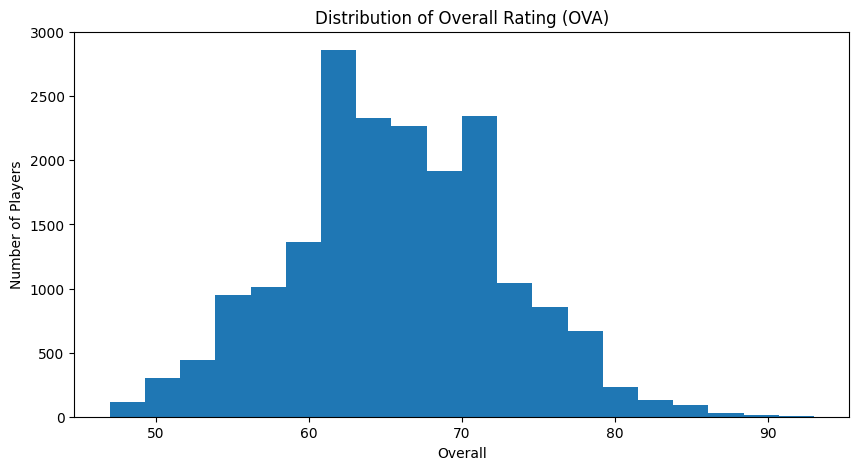

In [160]:
plt.figure(figsize=(10,5))
plt.hist(fifa['ova'], bins=20)
plt.title('Distribution of Overall Rating (OVA)')
plt.xlabel('Overall')
plt.ylabel('Number of Players')
plt.show()

## Insight — Distribution of Overall Rating (OVA)

The distribution of player overall ratings shows that most players are concentrated in the mid-rating range, with relatively fewer players in the extremely high or low rating categories. This indicates a normal talent distribution in professional football, where only a small number of elite players achieve top-tier ratings.

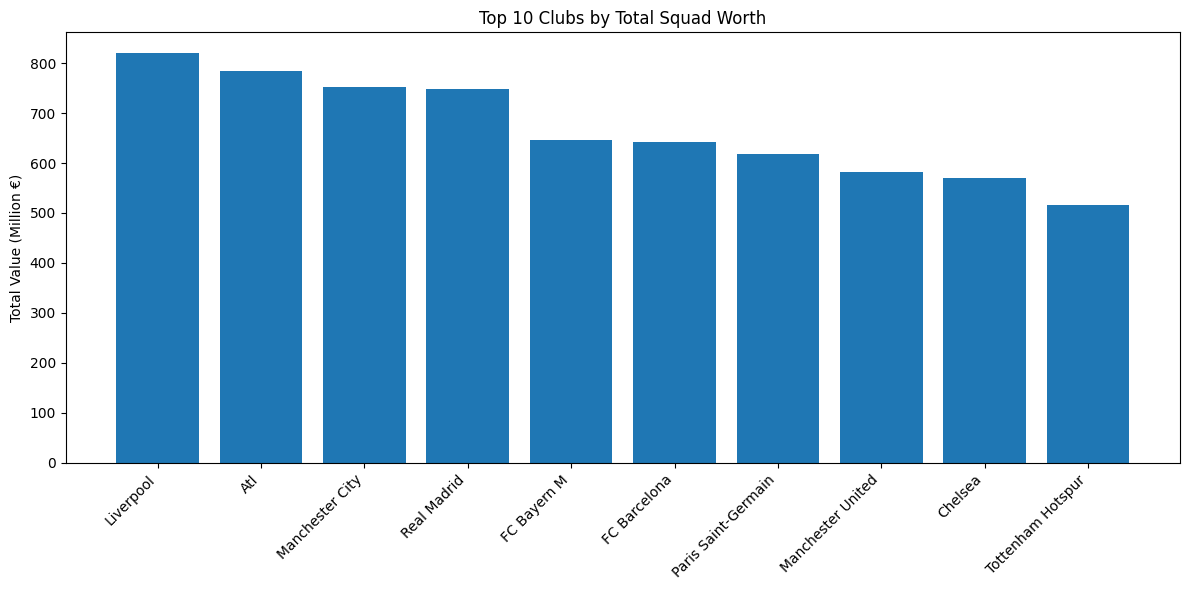

In [161]:
club_worth = fifa.groupby('club')['value_eur'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(club_worth.index, club_worth.values / 1e6)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Clubs by Total Squad Worth')
plt.ylabel('Total Value (Million €)')
plt.tight_layout()
plt.show()

## Insight — Top 10 Clubs by Total Squad Worth

The analysis shows that a small number of clubs dominate the transfer market in terms of total squad value. These clubs accumulate significantly higher financial strength due to their ability to acquire and retain high-value players.

This reflects real-world football economics where elite clubs maintain competitive advantage through stronger financial power, allowing them to build deeper and more expensive squads compared to smaller clubs.

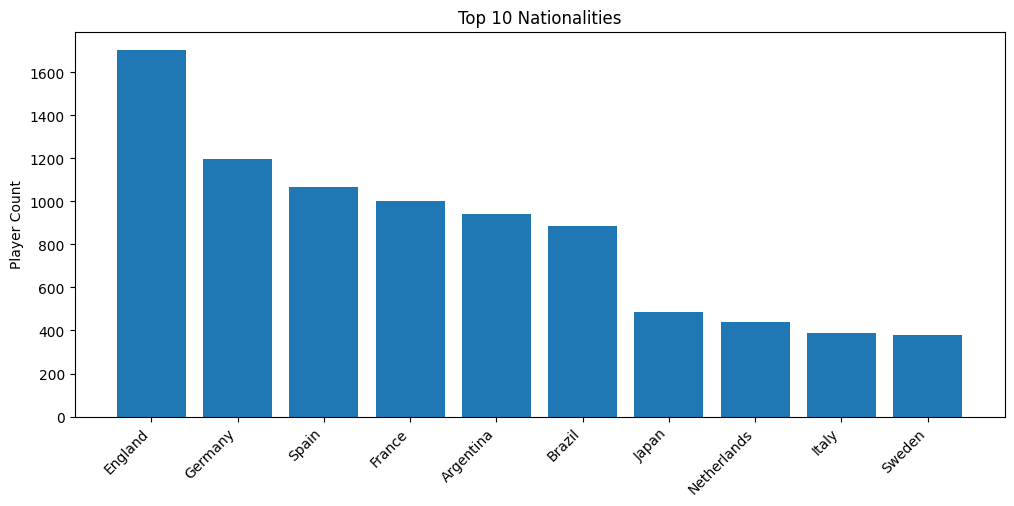

In [162]:
top_nat = fifa['nationality'].value_counts().head(10)

plt.figure(figsize=(12,5))
plt.bar(top_nat.index, top_nat.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Nationalities')
plt.ylabel('Player Count')
plt.show()

## Insight — Nationality Distribution

The dataset is heavily dominated by a few countries, especially major football nations. This reflects global football talent concentration, where certain countries consistently produce a larger number of professional players.

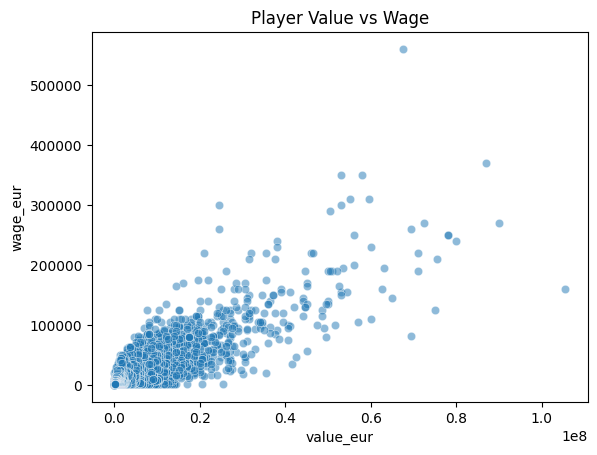

In [163]:
sns.scatterplot(x='value_eur', y='wage_eur', data=fifa, alpha=0.5)
plt.title('Player Value vs Wage')
plt.show()

## Insight — Player Value vs Wage

There is a general positive relationship between player value and wage, meaning higher-valued players tend to earn more. However, the spread is wide, indicating wage inefficiencies where some players are overpaid or undervalued relative to their market value.

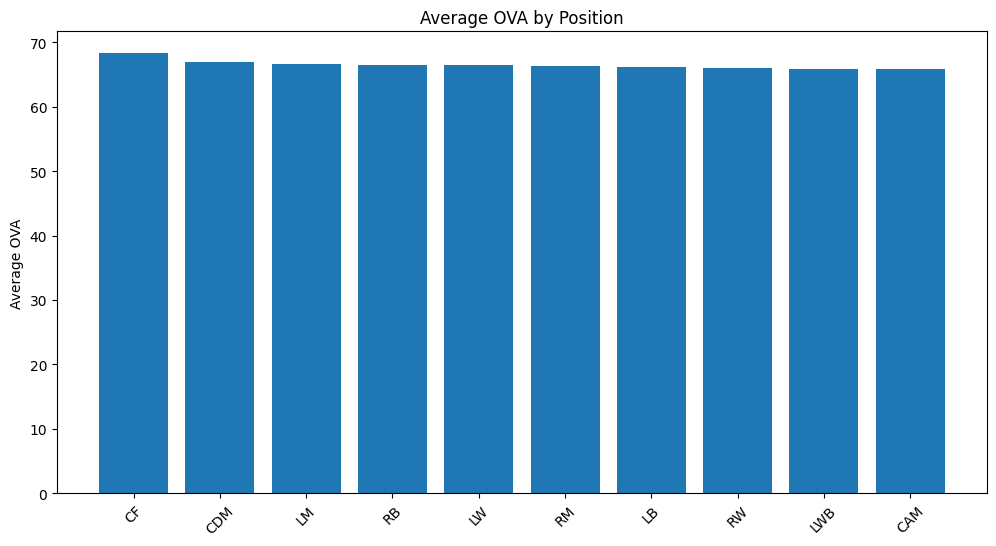

In [164]:
pos_rating = fifa.groupby('position')['ova'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(pos_rating.index, pos_rating.values)
plt.xticks(rotation=45)
plt.title('Average OVA by Position')
plt.ylabel('Average OVA')
plt.show()